In [6]:
import requests
import time
from dataclasses import dataclass
from typing import List, Dict, Tuple
from requests.exceptions import HTTPError

import feedparser
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# ========== 配置区 ==========

BASE_URL = "https://export.arxiv.org/api/query"  # 用 export 域名，比较稳

# 判定“量子金融”论文的关键词（可按你口味调整）
FINANCE_KEYWORDS = [
    "option pricing",
    "options pricing",
    "derivative pricing",
    "derivatives pricing",
    "portfolio optimisation",
    "portfolio optimization",
    "portfolio selection",
    "risk management",
    "credit risk",
    "xva",
    "cva",
    "financial",
    "finance",
]

# “量子数值/蒙特卡洛/PDE”这类更 general 的关键词，可以用来后面扩展 A/C 类逻辑
GENERAL_QUANTUM_NUMERICS = [
    "quantum monte carlo",
    "amplitude estimation",
    "qae",
    "quantum pde",
    "quantum differential equation",
]

# 粗筛：quant-ph + q-fin 里带 quantum 的论文
SEARCH_QUERY = "(cat:quant-ph OR cat:q-fin*) AND quantum"

START_YEAR = 2015
END_YEAR = 2026

# arXiv API 在 start 过大时易返回 500，设上限避免崩溃（建议 ≤5000）
MAX_START = 5000


# ========== 数据结构 ==========

@dataclass
class Paper:
    title: str
    abstract: str
    year: int
    authors: List[str]


@dataclass
class AuthorStats:
    name: str
    n_2018_2022_fin: int = 0
    n_2018_2022_total: int = 0
    n_2023_2026_fin: int = 0
    n_2023_2026_total: int = 0
    label: str = ""   # A_active / B_drop / C_shift / other


# ========== 工具函数 ==========

def query_arxiv(start: int, max_results: int = 100, max_retries: int = 3) -> List[Paper]:
    """从 arXiv API 拉一批论文，遇 5xx 时重试."""
    params = {
        "search_query": SEARCH_QUERY,
        "start": start,
        "max_results": max_results,
        "sortBy": "submittedDate",
        "sortOrder": "descending",  # 最新优先，才能拿到 2015–2026 的论文
    }
    for attempt in range(max_retries):
        try:
            resp = requests.get(BASE_URL, params=params, timeout=30)
            resp.raise_for_status()
            break
        except HTTPError as e:
            if 500 <= e.response.status_code < 600 and attempt < max_retries - 1:
                wait = (attempt + 1) * 5
                print(f"  [arXiv] start={start} 返回 {e.response.status_code}，{wait}s 后重试 ({attempt+1}/{max_retries})")
                time.sleep(wait)
            else:
                raise
    feed = feedparser.parse(resp.text)

    papers: List[Paper] = []
    for entry in feed.entries:
        year = int(entry.published[:4])
        title = entry.title or ""
        abstract = entry.summary or ""
        authors = [a.name for a in entry.authors]
        papers.append(
            Paper(
                title=title.lower(),
                abstract=abstract.lower(),
                year=year,
                authors=authors,
            )
        )
    return papers


def is_finance_paper(p: Paper) -> bool:
    text = f"{p.title} {p.abstract}"
    return any(k in text for k in FINANCE_KEYWORDS)


def is_general_q_numeric(p: Paper) -> bool:
    text = f"{p.title} {p.abstract}"
    return any(k in text for k in GENERAL_QUANTUM_NUMERICS)


def collect_papers(max_papers: int = 1000, batch: int = 100) -> Tuple[List[Paper], List[dict]]:
    """从 2015–2026 抓一批 candidate 论文，返回 (论文列表, 进度记录)."""
    all_papers: List[Paper] = []
    progress_log: List[dict] = []
    start = 0
    batch_num = 0

    while len(all_papers) < max_papers:
        if start >= MAX_START:
            print(f"  [arXiv] 已达 start 上限 {MAX_START}，停止抓取。已获 {len(all_papers)} 篇。")
            break
        try:
            papers = query_arxiv(start=start, max_results=batch)
        except HTTPError as e:
            print(f"  [arXiv] start={start} 请求失败: {e}，停止抓取。已获 {len(all_papers)} 篇。")
            break
        if not papers:
            break

        filtered = [p for p in papers if START_YEAR <= p.year <= END_YEAR]
        n_fin = sum(1 for p in filtered if is_finance_paper(p))
        batch_num += 1

        all_papers.extend(filtered)
        progress_log.append({
            "batch": batch_num,
            "cumulative": len(all_papers),
            "batch_size": len(filtered),
            "batch_finance": n_fin,
        })
        start += batch

        # arXiv 官方建议不要太频繁，这里稍微 sleep 一点
        time.sleep(3)

    return all_papers, progress_log


def build_author_stats(papers: List[Paper]) -> Dict[str, AuthorStats]:
    stats: Dict[str, AuthorStats] = {}

    for p in papers:
        fin_flag = is_finance_paper(p)
        gen_flag = is_general_q_numeric(p)  # 目前没直接用，但可以扩展 A/C 分类

        for raw_name in p.authors:
            name = raw_name.strip()
            if not name:
                continue
            if name not in stats:
                stats[name] = AuthorStats(name=name)
            s = stats[name]

            if 2018 <= p.year <= 2022:
                s.n_2018_2022_total += 1
                if fin_flag:
                    s.n_2018_2022_fin += 1

            if 2023 <= p.year <= 2026:
                s.n_2023_2026_total += 1
                if fin_flag:
                    s.n_2023_2026_fin += 1

    # 分配 A/B/C 标签
    for s in stats.values():
        # A 类：持续活跃（粗略版）
        if s.n_2018_2022_fin >= 1 and s.n_2023_2026_total > 0:
            # “每隔 1–2 年有输出” → 23–26 至少 2 篇金融 或 总数 >= 3
            if s.n_2023_2026_fin >= 2 or s.n_2023_2026_total >= 3:
                s.label = "A_active"

        # B 类：明显降档
        if s.n_2018_2022_fin >= 3:
            # 23–26 没有金融相关，或者整体发文量掉到原来一半以下
            if s.n_2023_2026_fin == 0 or s.n_2023_2026_total * 2 < max(1, s.n_2018_2022_total):
                s.label = "B_drop"

        # C 类：转领域（简化 proxy：以前有金融，23–26 有 paper 但金融篇数为 0）
        if s.n_2018_2022_fin >= 1 and s.n_2023_2026_total >= 1 and s.n_2023_2026_fin == 0:
            if s.label == "":
                s.label = "C_shift"

        if s.label == "":
            s.label = "other"

    return stats


def top_suspects(stats: Dict[str, AuthorStats], top_n: int = 50) -> List[AuthorStats]:
    """挑出 B + C 类里，2018–2022 金融论文数最多的一批."""
    candidates = [s for s in stats.values() if s.label in {"B_drop", "C_shift"}]
    candidates.sort(key=lambda s: s.n_2018_2022_fin, reverse=True)
    return candidates[:top_n]


# ========== 主流程 ==========

# 1）抓论文（返回论文列表 + 进度记录）
papers, progress_log = collect_papers(max_papers=500)

# 2）统计作者
stats = build_author_stats(papers)

# 3）拿到"疑似 2023–2026 消失/转向"的作者列表
suspects = top_suspects(stats, top_n=50)


  [arXiv] 已达 start 上限 5000，停止抓取。已获 0 篇。


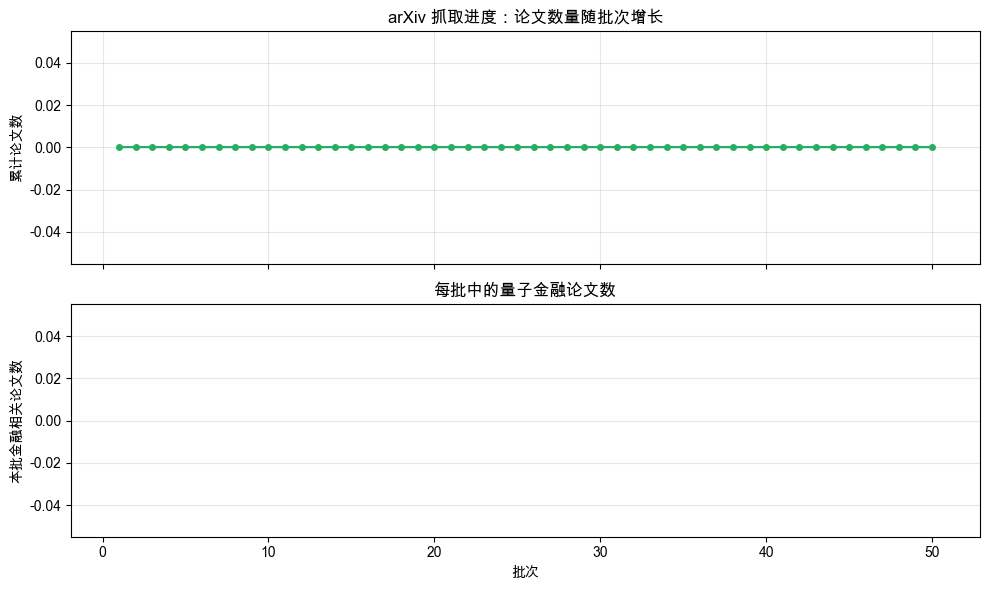

In [10]:
# ========== 可视化 1：抓取进度 ==========
# 展示每批 API 请求后累计获取的论文数量，以及每批中金融相关论文数
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

batches = [p["batch"] for p in progress_log]
cumulative = [p["cumulative"] for p in progress_log]
batch_fin = [p["batch_finance"] for p in progress_log]

axes[0].fill_between(batches, cumulative, alpha=0.6, color="#2ecc71")
axes[0].plot(batches, cumulative, "o-", color="#27ae60", markersize=4)
axes[0].set_ylabel("累计论文数")
axes[0].set_title("arXiv 抓取进度：论文数量随批次增长")
axes[0].grid(True, alpha=0.3)

axes[1].bar(batches, batch_fin, color="#3498db", alpha=0.8, width=0.8)
axes[1].set_xlabel("批次")
axes[1].set_ylabel("本批金融相关论文数")
axes[1].set_title("每批中的量子金融论文数")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

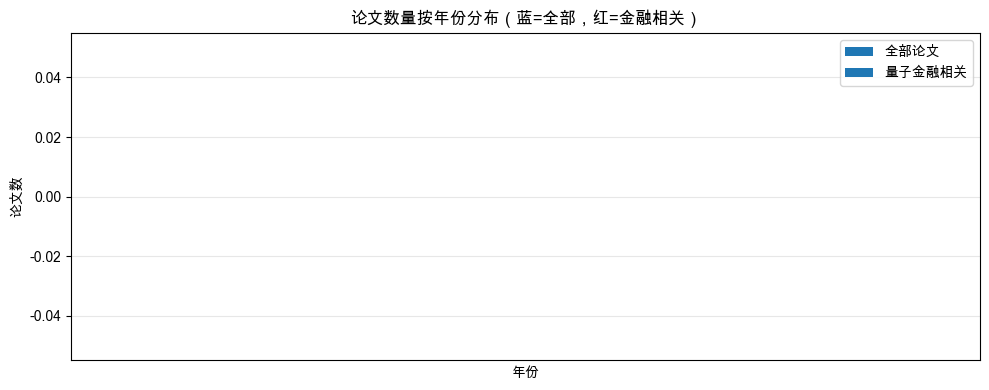

In [ ]:
# ========== 可视化 2：论文年份分布 ==========
from collections import Counter
year_counts = Counter(p.year for p in papers)
years = sorted(year_counts.keys())
counts = [year_counts[y] for y in years]
fin_counts = [sum(1 for p in papers if p.year == y and is_finance_paper(p)) for y in years]

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(years))
w = 0.35
ax.bar([i - w/2 for i in x], counts, w, label="全部论文", color="#3498db", alpha=0.8)
ax.bar([i + w/2 for i in x], fin_counts, w, label="量子金融相关", color="#e74c3c", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_xlabel("年份")
ax.set_ylabel("论文数")
ax.set_title("论文数量按年份分布（蓝=全部，红=金融相关）")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [12]:
# ========== 可视化 3：作者分类分布 ==========
label_counts = Counter(s.label for s in stats.values())
labels = ["A_active", "B_drop", "C_shift", "other"]
counts = [label_counts.get(l, 0) for l in labels]
colors = ["#2ecc71", "#e74c3c", "#f39c12", "#95a5a6"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].pie(counts, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
axes[0].set_title("作者分类占比")

axes[1].bar(labels, counts, color=colors)
axes[1].set_ylabel("作者数")
axes[1].set_title("各分类作者数量")
for i, v in enumerate(counts):
    axes[1].text(i, v + 2, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

/Users/junchishen/miniconda3/envs/quant_blueqat/lib/python3.11/site-packages/matplotlib/axes/_axes.py:3368: RuntimeWarning: invalid value encountered in divide
  x = x / sx


ValueError: cannot convert float NaN to integer

ValueError: need at least one array to concatenate

<Figure size 1000x400 with 2 Axes>

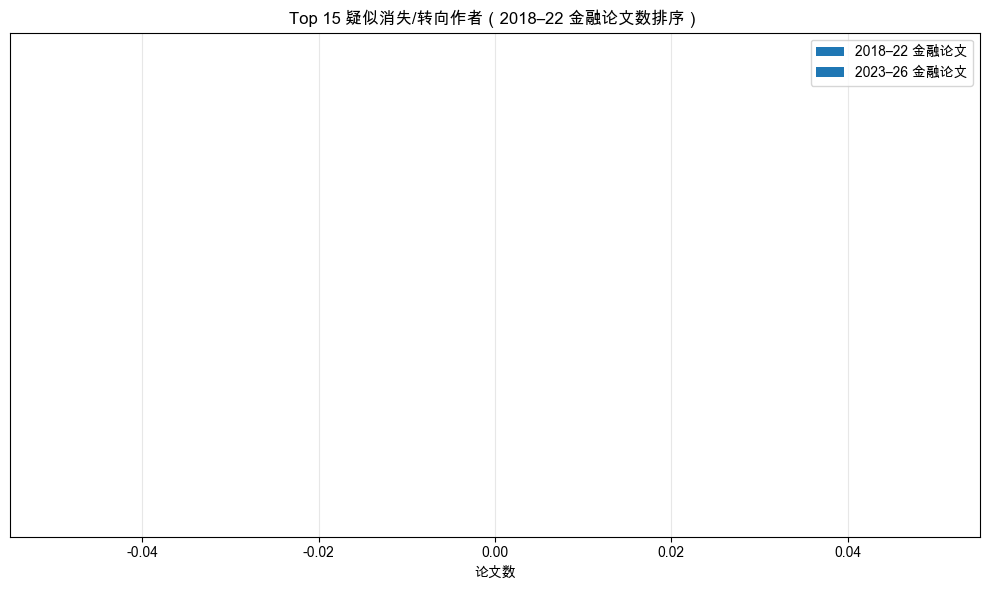

In [ ]:
# ========== 可视化 4：Top 疑似作者（B/C 类） ==========
top_n = 15
top_s = suspects[:top_n]
names = [s.name[:20] + "…" if len(s.name) > 20 else s.name for s in top_s]
fin_1822 = [s.n_2018_2022_fin for s in top_s]
fin_2326 = [s.n_2023_2026_fin for s in top_s]

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(names))
h = 0.35
bars1 = ax.barh([i - h/2 for i in x], fin_1822, h, label="2018–22 金融论文", color="#3498db", alpha=0.8)
bars2 = ax.barh([i + h/2 for i in x], fin_2326, h, label="2023–26 金融论文", color="#e74c3c", alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel("论文数")
ax.set_title("Top 15 疑似消失/转向作者（2018–22 金融论文数排序）")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

In [ ]:
# 输出 CSV 格式，方便导入 Excel / pandas
print("name,2018_22_fin,2018_22_total,2023_26_fin,2023_26_total,label")
for s in suspects:
    print(f"{s.name},{s.n_2018_2022_fin},{s.n_2018_2022_total},{s.n_2023_2026_fin},{s.n_2023_2026_total},{s.label}")